# Hệ Thống Đánh Giá Tín Dụng (Credit Scoring) Bằng Xác Suất & Machine Learning
**Dự án Colab hoàn chỉnh - Thay thế phân loại Có/Không bằng Điểm số tín dụng chuyên sâu**

### Giới thiệu
Trong ngành tài chính - ngân hàng, việc chỉ phân loại khách hàng thành hai nhóm **Có nợ xấu (1)** hoặc **Không nợ xấu (0)** là chưa đủ cho mục đích ra quyết định kinh doanh. Thay vào đó, các tổ chức tín dụng sử dụng **Xác suất vỡ nợ (Probability of Default - PD)** để chuyển đổi thành **Điểm số tín dụng (Credit Score)**.

**Lợi ích của phương pháp này:**
1. **Phân nhóm rủi ro mịn hơn:** Giúp định giá lãi suất theo rủi ro (Risk-based pricing).
2. **Hỗ trợ phê duyệt tự động:** Đặt các ngưỡng cắt (Cut-off scores) tùy thuộc vào khẩu vị rủi ro của ngân hàng.
3. **Quản trị danh mục hiệu quả:** Theo dõi xu hướng dịch chuyển rủi ro của khách hàng theo thời gian.

Notebook này sử dụng mô hình **HistGradientBoostingClassifier** (mạnh mẽ, xử lý tốt dữ liệu khuyết thiếu và bất đối xứng) để dự báo xác suất và chuyển đổi sang thang điểm chuẩn **300 - 850**.

## 1. Khai báo thư viện cần thiết

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from scipy.stats import ks_2samp

# Cấu hình biểu đồ
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

## 2. Đọc và Kiểm tra Dữ liệu

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Cập nhật đường dẫn nếu file của bạn nằm ở thư mục khác
train_path = '/content/drive/MyDrive/DataScience/cs-training.csv'
test_path = '/content/drive/MyDrive/DataScience/cs-test.csv'

try:
    train_raw = pd.read_csv(train_path)
    external_test_raw = pd.read_csv(test_path)

    # Gán vào biến train_df để các ô sau có thể sử dụng
    train_df = train_raw.copy()

    print('Đã tải dữ liệu từ Google Drive thành công!')
except FileNotFoundError:
    print('Không tìm thấy file. Vui lòng kiểm tra lại đường dẫn trên Google Drive.')
except Exception as e:
    print(f'Đã xảy ra lỗi: {e}')

Đã tải dữ liệu từ Google Drive thành công!


## 3. Phân Tách Dữ Liệu Train/Validation

In [ ]:
# Kiểm tra nếu train_df đã được tải thành công từ Drive
if 'train_df' in globals() and train_df is not None:
    # Loại bỏ cột Unnamed: 0 nếu có
    if 'Unnamed: 0' in train_df.columns:
        train_df = train_df.drop(columns=['Unnamed: 0'])

    # Tách các tính năng (X) và nhãn mục tiêu (y)
    X = train_df.drop(columns=['SeriousDlqin2yrs'])
    y = train_df['SeriousDlqin2yrs']

    # Chia dữ liệu theo tỷ lệ 80% Train - 20% Validation
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Tải dữ liệu thành công!")
    print(f"Số lượng mẫu tập Train: {X_train.shape[0]}")
    print(f"Số lượng mẫu tập Validation: {X_val.shape[0]}")
    print(f"Tỷ lệ nợ xấu trong tập Train: {y_train.mean():.2%}")
else:
    print("LỖI: Biến 'train_df' chưa có dữ liệu. Hãy chạy lại ô lệnh tải dữ liệu từ Drive ở trên.")

Tải dữ liệu thành công!
Số lượng mẫu tập Train: 120000
Số lượng mẫu tập Validation: 30000
Tỷ lệ nợ xấu trong tập Train: 6.68%


## 4. Xây Dựng Mô Hình Dự Báo Xác Suất (Probability Estimation)

Sử dụng `HistGradientBoostingClassifier` của Scikit-Learn. Đây là thuật toán dựa trên LightGBM, có tốc độ xử lý cực nhanh, tự động xử lý các giá trị khuyết thiếu (`NaN`) một cách tối ưu mà không cần ép giá trị (imputation) thủ công, và chống Overfitting tốt.

In [ ]:
# Khởi tạo và huấn luyện mô hình
model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.05,
    random_state=42
)
model.fit(X_train, y_train)

# Dự báo xác suất xảy ra nợ xấu (PD - Probability of Default)
pd_train = model.predict_proba(X_train)[:, 1]
pd_val = model.predict_proba(X_val)[:, 1]

print("Huấn luyện mô hình hoàn tất!")

Huấn luyện mô hình hoàn tất!


## 5. Đánh Giá Mô Hình Bằng Các Chỉ Số Rủi Rủi Tín Dụng Chuẩn

Trong rủi ro tín dụng, 3 chỉ số quan trọng nhất là:
1. **ROC-AUC:** Khả năng phân biệt giữa hồ sơ Tốt và Xấu.
2. **Hệ số Gini:** $Gini = 2 \times AUC - 1$. Chỉ số Gini càng cao, mô hình càng mạnh.
3. **Chỉ số KS (Kolmogorov-Smirnov):** Đo lường khoảng cách lớn nhất giữa phân phối tích lũy của khách hàng Tốt và khách hàng Xấu. (KS > 0.4 được coi là rất tốt).

==> Chỉ số Đánh giá trên tập Validation:
- ROC-AUC  : 0.8684
- Gini      : 0.7368
- Chỉ số KS : 0.5804


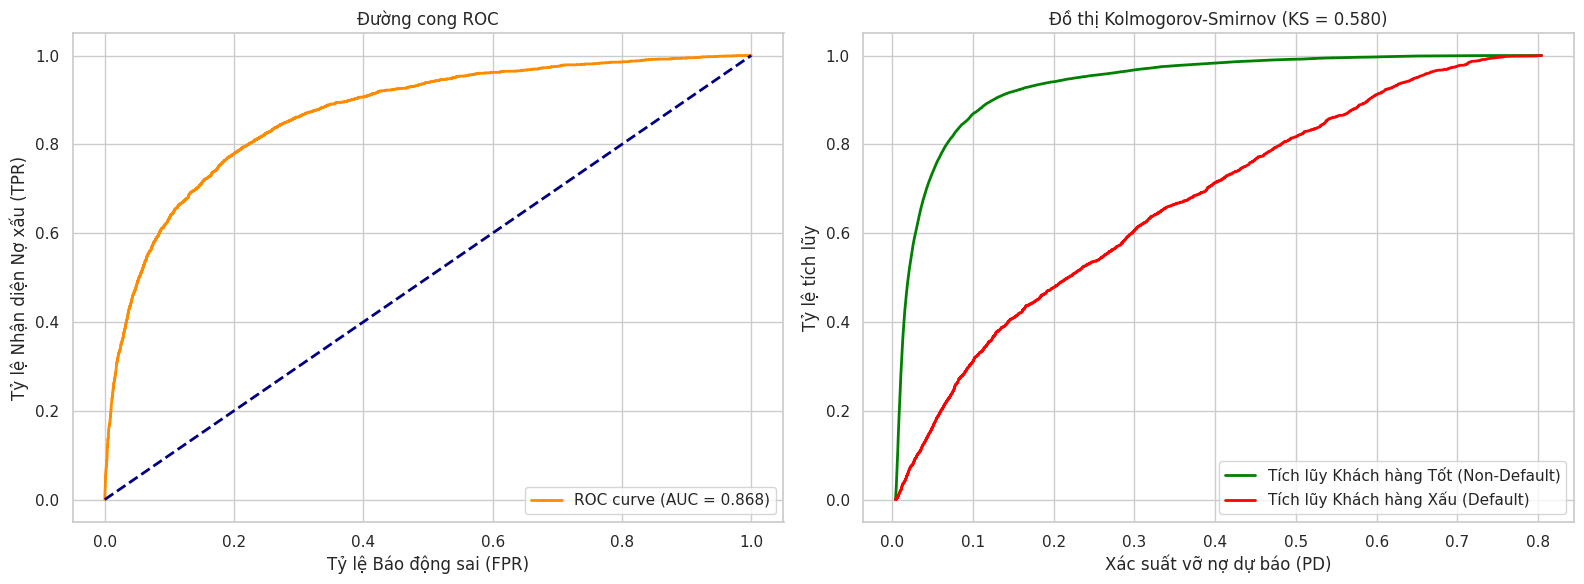

In [ ]:
# Tính toán chỉ số
auc_score = roc_auc_score(y_val, pd_val)
gini_score = 2 * auc_score - 1

def compute_ks(y_true, y_prob):
    df = pd.DataFrame({'label': y_true, 'prob': y_prob})
    df = df.sort_values(by='prob').reset_index(drop=True)
    df['good'] = 1 - df['label']
    df['bad'] = df['label']
    df['cum_good'] = df['good'].cumsum() / df['good'].sum()
    df['cum_bad'] = df['bad'].cumsum() / df['bad'].sum()
    ks_stat = max(abs(df['cum_good'] - df['cum_bad']))
    return ks_stat, df

ks_stat, ks_df = compute_ks(y_val, pd_val)

print(f"==> Chỉ số Đánh giá trên tập Validation:")
print(f"- ROC-AUC  : {auc_score:.4f}")
print(f"- Gini      : {gini_score:.4f}")
print(f"- Chỉ số KS : {ks_stat:.4f}")

# Vẽ đồ thị ROC và đồ thị KS
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Đường cong ROC
fpr, tpr, _ = roc_curve(y_val, pd_val)
ax[0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
ax[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[0].set_xlabel('Tỷ lệ Báo động sai (FPR)')
ax[0].set_ylabel('Tỷ lệ Nhận diện Nợ xấu (TPR)')
ax[0].set_title('Đường cong ROC')
ax[0].legend(loc="lower right")

# 2. Đồ thị KS
ax[1].plot(ks_df['prob'], ks_df['cum_good'], label='Tích lũy Khách hàng Tốt (Non-Default)', color='green', lw=2)
ax[1].plot(ks_df['prob'], ks_df['cum_bad'], label='Tích lũy Khách hàng Xấu (Default)', color='red', lw=2)
ax[1].set_xlabel('Xác suất vỡ nợ dự báo (PD)')
ax[1].set_ylabel('Tỷ lệ tích lũy')
ax[1].set_title(f'Đồ thị Kolmogorov-Smirnov (KS = {ks_stat:.3f})')
ax[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 6. Chuyển Đổi Xác Suất Thành Điểm Số Tín Dụng (Credit Score)

Thay vì dùng xác suất dạng thập phân khó đọc, chúng ta sẽ ánh xạ sang thang điểm chuẩn từ **300 đến 850** bằng hàm Log-odds định chuẩn tuyến tính.
- Khách hàng có xác suất vỡ nợ **thấp** sẽ có điểm số **cao** (an toàn).
- Khách hàng có xác suất vỡ nợ **cao** sẽ có điểm số **thấp** (rủi ro).

In [ ]:
def prob_to_credit_score(p, min_score=300, max_score=850):
    """
    Chuyển đổi xác suất vỡ nợ (PD) thành Điểm số tín dụng chuẩn hóa từ 300 - 850
    """
    p = np.clip(p, 0.0005, 0.9995) # Giới hạn biên tránh lỗi log(0) hoặc chia cho 0
    log_odds = np.log((1 - p) / p)

    # Định nghĩa dải log-odds để ánh xạ vào khoảng 300 - 850
    min_log_odds = -3.0
    max_log_odds = 7.0

    # Nội suy tuyến tính
    score = min_score + (max_score - min_score) * (log_odds - min_log_odds) / (max_log_odds - min_log_odds)
    return np.clip(np.round(score).astype(int), min_score, max_score)

# Tính toán điểm số cho tập Validation
scores_val = prob_to_credit_score(pd_val)

val_results = pd.DataFrame({
    'Actual_Status': y_val,
    'PD': pd_val,
    'CreditScore': scores_val
})

print("Thống kê mô tả Điểm số tín dụng vừa tạo:")
print(val_results['CreditScore'].describe())

Thống kê mô tả Điểm số tín dụng vừa tạo:
count    30000.000000
mean       656.999133
std         74.752295
min        387.000000
25%        613.000000
50%        673.000000
75%        715.000000
max        770.000000
Name: CreditScore, dtype: float64


## 7. Phân Nhóm Hạng Rủi Rủi (Risk Tiering) & Kiểm Chứng Thực Tế

Chúng ta sẽ chia khách hàng thành 5 phân hạng rủi ro dựa trên Điểm số:
1. **Xuất sắc (Excellent):** >= 750
2. **Tốt (Good):** 700 - 749
3. **Trung bình (Fair):** 630 - 699
4. **Kém (Poor):** 550 - 629
5. **Rất kém (Very Poor):** < 550

Mô hình chuẩn xác phải chứng minh được: **Điểm số càng cao thì Tỷ lệ nợ xấu thực tế (Default Rate) càng thấp**.

In [ ]:
def get_risk_tier(score):
    if score >= 750: return '1. Excellent (Xuất sắc)'
    elif score >= 700: return '2. Good (Tốt)'
    elif score >= 630: return '3. Fair (Trung bình)'
    elif score >= 550: return '4. Poor (Kém)'
    else: return '5. Very Poor (Rất kém)'

val_results['Risk_Tier'] = val_results['CreditScore'].apply(get_risk_tier)

# Kiểm chứng tỷ lệ nợ xấu thực tế trên từng hạng điểm
tier_summary = val_results.groupby('Risk_Tier').agg(
    Total_Customers=('Actual_Status', 'count'),
    Bad_Customers=('Actual_Status', 'sum'),
    Default_Rate=('Actual_Status', 'mean')
).reset_index()

tier_summary['Default_Rate_Pct'] = tier_summary['Default_Rate'].map(lambda x: f"{x:.2%}")
print("=== BẢNG KIỂM CHỨNG HẠNG RỦI RO (MÔ HÌNH CHUẨN ĐỀU CÓ TỶ LỆ GIẢM DẦN) ===")
display(tier_summary)

=== BẢNG KIỂM CHỨNG HẠNG RỦI RO (MÔ HÌNH CHUẨN ĐỀU CÓ TỶ LỆ GIẢM DẦN) ===


,Risk_Tier,Total_Customers,Bad_Customers,Default_Rate,Default_Rate_Pct
0,1. Excellent (Xuất sắc),1482,4,0.002699,0.27%
1,2. Good (Tốt),9323,68,0.007294,0.73%
2,3. Fair (Trung bình),9866,239,0.024225,2.42%
3,4. Poor (Kém),6338,585,0.092300,9.23%
4,5. Very Poor (Rất kém),2991,1109,0.370779,37.08%


## 8. Trực Quan Hóa Phân Phối Điểm Số & Tỷ Lệ Nợ Xấu

/tmp/ipykernel_2199/139583253.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_summary, x='Risk_Tier', y='Default_Rate', ax=ax[1], palette='Reds_r')


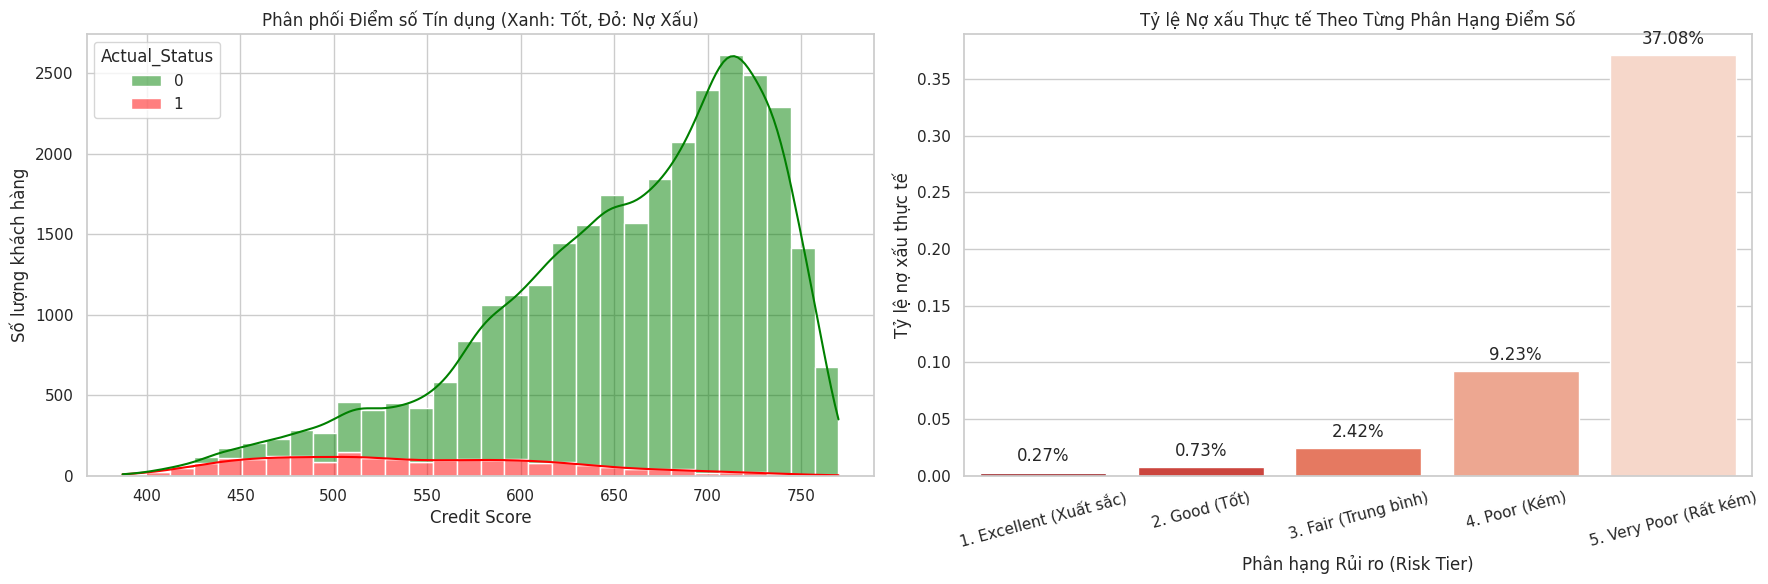

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Phân phối điểm số tách biệt giữa khách hàng Tốt và Xấu
sns.histplot(data=val_results, x='CreditScore', hue='Actual_Status', bins=30, kde=True, ax=ax[0], palette={0: 'green', 1: 'red'}, multiple='stack')
ax[0].set_title('Phân phối Điểm số Tín dụng (Xanh: Tốt, Đỏ: Nợ Xấu)')
ax[0].set_xlabel('Credit Score')
ax[0].set_ylabel('Số lượng khách hàng')

# 2. Trực quan hóa tỷ lệ nợ xấu thực tế theo phân hạng
sns.barplot(data=tier_summary, x='Risk_Tier', y='Default_Rate', ax=ax[1], palette='Reds_r')
ax[1].set_title('Tỷ lệ Nợ xấu Thực tế Theo Từng Phân Hạng Điểm Số')
ax[1].set_xlabel('Phân hạng Rủi ro (Risk Tier)')
ax[1].set_ylabel('Tỷ lệ nợ xấu thực tế')
for p in ax[1].patches:
    ax[1].annotate(f"{p.get_height():.2%}", (p.get_x() + p.get_width() / 2., p.get_height() + 0.01), ha='center')

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 9. Ứng Dụng Trên Tập Dữ Liệu Thử Nghiệm (Test Set) & Xuất Báo Cáo

Tiến hành áp dụng mô hình lên tệp dữ liệu test để phục vụ ra quyết định cấp tín dụng thực tế.

In [ ]:
try:
    # Sử dụng biến test_path đã định nghĩa ở trên để đọc file từ Drive
    test_df = pd.read_csv(test_path).drop(columns=['Unnamed: 0', 'SeriousDlqin2yrs'], errors='ignore')

    # Dự báo PD trên tập test
    pd_test = model.predict_proba(test_df)[:, 1]

    # Quy đổi điểm số trên tập test
    scores_test = prob_to_credit_score(pd_test)

    # Tạo dataframe kết quả cuối cùng
    test_output = pd.read_csv(test_path)
    test_output['Predicted_Probability_of_Default'] = pd_test
    test_output['Credit_Score'] = scores_test
    test_output['Risk_Tier'] = test_output['Credit_Score'].apply(get_risk_tier)

    # Lưu kết quả đầu ra
    test_output.to_csv('credit_scoring_test_results.csv', index=False)
    print("Đã dự báo và lưu kết quả thành công vào file 'credit_scoring_test_results.csv'!")
    print("\n5 dòng kết quả mẫu cho phòng Quản trị rủi ro:")
    display(test_output[['Credit_Score', 'Predicted_Probability_of_Default', 'Risk_Tier']].head())

except FileNotFoundError:
    print(f"Không tìm thấy file tại đường dẫn: {test_path}")
except Exception as e:
    print(f"Đã xảy ra lỗi trong quá trình dự báo: {e}")

Đã dự báo và lưu kết quả thành công vào file 'credit_scoring_test_results.csv'!

5 dòng kết quả mẫu cho phòng Quản trị rủi ro:


,Credit_Score,Predicted_Probability_of_Default,Risk_Tier
0,601,0.077531,4. Poor (Kém)
1,624,0.052363,4. Poor (Kém)
2,710,0.011437,2. Good (Tốt)
3,605,0.072341,4. Poor (Kém)
4,578,0.113311,4. Poor (Kém)
